In [1]:
import os
import pickle
import numpy as np
import pandas as pd

from collections import Counter
from matplotlib import pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.stats import chi2

# Data

In [2]:
# Read Annotation Data
path = '../data/Final annotations.xlsx'
xlsx = pd.ExcelFile(path)
annots = {
    sheet.lower().replace('sujet ', 's').replace(' ', '_'): 
    pd.read_excel(path, sheet_name=sheet) for sheet in xlsx.sheet_names
}

# Read Prompt Data
path = '../data/Prompts.xlsx'
xlsx = pd.ExcelFile(path)
prompts = {
    sheet: 
    pd.read_excel(path, sheet_name=sheet) for sheet in xlsx.sheet_names
}

# Read labels Data
path = '../data/Final labels.xlsx'
labels = pd.read_excel(path, sheet_name='eurometric')
labels = labels.rename(columns={'Euro?': 'euro', 'Metric':'unit', 'RID':'rid', 'Exercice': 'exo'})

In [3]:
# Create new dataframe
def choose_exercise(row, default='Mai'):
    if 'decision' == 'check':
        return row[default]
    elif 'decision' == 'Mai':
        return row['Mai']
    else:
        return row['Tuan Tu']

ann = pd.DataFrame()
ann['rid'] = annots['contexte']['RID']
ann['exo'] = annots['contexte']['Exercice']
ann['contexte'] = annots['contexte'].apply(lambda row: choose_exercise(row, 'Tuan Tu'), axis=1)
ann['objects'] = annots['objects'].apply(lambda row: choose_exercise(row, 'Tuan Tu'), axis=1)
ann['pluriels'] = annots['pluriels'].apply(lambda row: choose_exercise(row, 'Mai'), axis=1)
ann['s1'] = annots['s1'].apply(lambda row: choose_exercise(row, 'Mai'), axis=1)
ann['genre_s1'] = annots['genre_s1'].apply(lambda row: choose_exercise(row, 'Mai'), axis=1)
ann['origine_s1'] = annots['origine_s1'].apply(lambda row: choose_exercise(row, 'Mai'), axis=1)
ann['traits_s1'] = annots['traits_s1'].apply(lambda row: choose_exercise(row, 'Mai'), axis=1)
ann['s2'] = annots['s2'].apply(lambda row: choose_exercise(row, 'Mai'), axis=1)
ann['genre_s2'] = annots['genre_s2'].apply(lambda row: choose_exercise(row, 'Mai'), axis=1)
ann['origine_s2'] = annots['origine_s2'].apply(lambda row: choose_exercise(row, 'Mai'), axis=1)

ann = ann.merge(prompts['rid'][['id', 'exo']], on='exo', how='left')
ann = ann.merge(prompts['setup'][['id', 'theme', 'persona', 'eleves', 'LLM', 'n', 'prompt']], on='id', how='left')
ann = ann.merge(labels[['exo', 'euro', 'unit']], on='exo')

ann['unique_prompt'] = ann['prompt'].apply(lambda prompt: prompt.split('Donne-moi')[0])
ann = ann.fillna('x')
unique_prompts = [u for u in ann['unique_prompt'].unique()]
unique_prompts = {unique_prompts[i]: i for i in range(len(unique_prompts))}

up = {0: 'simple', 1: 'inclusif', 2: 'prof'}
ann['prompt_index'] = ann['unique_prompt'].apply(lambda p: up[unique_prompts[p]])

# Analysis

## Cohen Kappa


In [4]:
def compute_cohen_kappa(df):
    # Column separation
    mai = df['Mai']
    tt = df['Tuan Tu']
    d = df['Décision']

    # Data preparation
    mai_labels = Counter(mai)
    tt_labels = Counter(tt)

    # P0: Agreement
    p0 = len(d[(d == 'check') | (d == 'additional info')]) / len(mai)

    # PE: probability of random agreement
    label_pe = []
    for label in (mai + tt).unique():
        label_pe.append((
            mai_labels[label] / len(mai)
        ) * (
            tt_labels[label] / len(tt)
        ))
    pe = np.sum(label_pe)
    return (p0 - pe) / (1 - pe)

for column in annots:
    print('{}{}: {}'.format(column[0].upper(), column[1:].lower(), round(compute_cohen_kappa(annots[column]), 2)))
    print()

Objects: 0.79

Pluriels: 0.85

S1: 0.92

Genre_s1: 0.86

Origine_s1: 0.98

Contexte: 0.98

Traits_s1: 0.76

S2: 0.72

Genre_s2: 0.64

Origine_s2: 1.0



## Inclusivity Analysis

In [5]:
def lrt(full_model, reduced_model, df_diff):
    stat = 2 * (full_model.llf - reduced_model.llf)
    return chi2.sf(stat, df=df_diff)

def compute_differences(column, positive_categories, df):
    """
    Create model to test the difference for each column

    column: col of the dataframe to check what 
    positive categories: the thing we want to test whether it appears more or not (for example is it more inclusive) -> in other words,      the inclusive categories
    """

    data = pd.DataFrame()
    pos_col = []
    llm_col = []
    prompt_col = []
    mask_col = []
    for col in column.split(' + '):
        pos_col += [p for p in df[col].isin(positive_categories).astype(int)]
        llm_col += [l for l in df['LLM']]
        prompt_col += [p for p in df['prompt_index']]
        mask_col += [m for m in (df[col] != 'x')]
        
    data['positive'] = pos_col
    data['llm'] = llm_col
    data['prompt'] = prompt_col
    data = data[mask_col]

    full = smf.logit(f"positive ~ C(prompt) + C(llm):C(prompt)", data=data).fit(disp=0)
    no_inter = smf.logit(f"positive ~ C(llm) + C(prompt)", data=data).fit(disp=0)
    no_llm = smf.logit(f"positive ~ C(prompt)", data=data).fit(disp=0)
    no_prompt = smf.logit(f"positive ~ C(llm)", data=data).fit(disp=0)

    models = {
        'p_llm': lrt(no_inter, no_llm, df_diff=1),
        'p_prompt': lrt(no_inter, no_prompt, df_diff=2),
        'p_inter': lrt(full, no_inter, df_diff=2)
    }

    return models


### Pluriels

In [6]:
# Check whether the pluriels have an effect -> No
p_plur = compute_differences('pluriels', ['inclusif'], ann)

In [7]:
_, corrected, _, _ = multipletests(
    [
        p_plur['p_llm'], p_plur['p_prompt'], p_plur['p_inter'],
    ], method='fdr_bh'
)

names = [
    'use of inclusive pluriel: llm effect', 'use of inclusive pluriel: prompt effect', 'use of inclusive pluriel: interaction effect',
]

for i_n, name in enumerate(names):
    if corrected[i_n] < 0.05:
        print('Significant {} (p={})'.format(name, round(corrected[i_n], 6)))

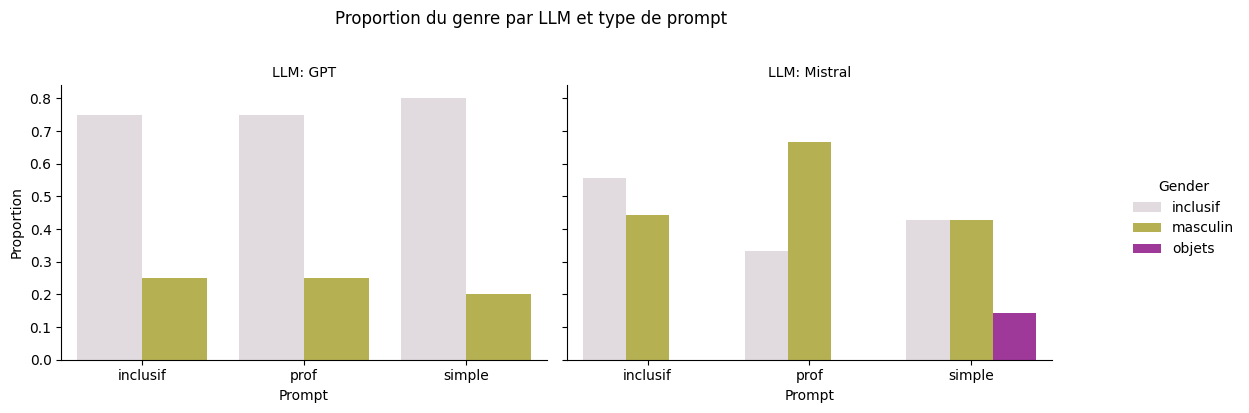

In [8]:
pluriel = ann[ann['pluriels']!='x']
pluriel = pluriel.groupby(['LLM', 'prompt_index'])['pluriels'].value_counts().reset_index()
pluriel["prop"] = (
    pluriel
    .groupby(["LLM", "prompt_index"])["count"]
    .transform(lambda x: x / x.sum())
)

g = sns.FacetGrid(pluriel, col="LLM", height=4, aspect=1.2, sharey=True)
g.map_dataframe(
    sns.barplot,
    x="prompt_index",
    y="prop",
    hue="pluriels",
    palette = {
        "x":             "#2E68BB",
        "masculin":            "#C6C042",
        "objets":      "#AF28AA",
        "inclusif": "#E2DAE0",
    }
    #order=["simple", "prof", "inclusif"],
)
g.set_axis_labels("Prompt", "Proportion")
g.set_titles(col_template="LLM: {col_name}")
g.add_legend(title="Gender", bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.suptitle("Proportion du genre par LLM et type de prompt", y=1.02)
plt.tight_layout()
plt.show()

In [9]:
pluriels = ann[ann['pluriels']!='x']
print(
    'Proportion d inclusif:', len(pluriels[pluriels['pluriels'] == 'inclusif']) / len(pluriels),
    '\n'
    'Proportion de masculin:', len(pluriels[pluriels['pluriels'] == 'masculin']) /len(pluriels)
)

Proportion d inclusif: 0.59375 
Proportion de masculin: 0.375


### Gender

In [10]:
# Check whether the genre of the first subject has an effect
pmasc = compute_differences(
    'genre_s1 + genre_s2', ['masculin'], ann
)
print('Masculin')
print(pmasc)

pinc = compute_differences(
    'genre_s1 + genre_s2', ['neutre (objet)', 'féminin et masculin'], ann
)
print('Inclusive')
print(pinc)

Masculin
{'p_llm': np.float64(0.03791256368186412), 'p_prompt': np.float64(0.0008724204866576212), 'p_inter': np.float64(0.8846760061786683)}
Inclusive
{'p_llm': np.float64(0.005035967823775759), 'p_prompt': np.float64(0.0016673044721679903), 'p_inter': np.float64(0.29383072956565076)}


/Users/cock/miniconda3/envs/llm-blabla/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [11]:
_, corrected, _, _ = multipletests(
    [
        pmasc['p_llm'], pmasc['p_prompt'], pmasc['p_inter'],
        pinc['p_llm'], pinc['p_prompt'], pinc['p_inter']
    ], method='fdr_bh'
)

names = [
    'use of masculine: llm effect', 'use of masculine: prompt effect', 'use of masculine: interaction effect',
    'use of inclusive: llm effect', 'use of inclusive: prompt effect', 'use of inclusive: interaction effect'
]

for i_n, name in enumerate(names):
    if corrected[i_n] < 0.05:
        print('Significant {} (p={})'.format(name, round(corrected[i_n], 6)))

Significant use of masculine: prompt effect (p=0.005002)
Significant use of inclusive: llm effect (p=0.010072)
Significant use of inclusive: prompt effect (p=0.005002)


### Origin

In [12]:
# continent mapping
def get_continent(countries):
    if 'Arabic' in countries:
        return 'African-Asian'

    elif 'French' in countries:
        return 'Europe'
    elif 'x' == countries:
        return 'x'
    print(error)



In [13]:
ts1 = ann[['rid', 's1', 'origine_s1', 'id', 'persona', 'eleves', 'LLM', 'n', 'prompt', 'exo', 'prompt_index']]
ts1['continent'] = ts1['origine_s1'].apply(lambda origin: get_continent(origin))
ts1 = ts1[ts1['continent'] != 'x']

ts2 = ann[['rid', 'origine_s2', 'id', 'persona', 'eleves', 'LLM', 'n', 'prompt', 'exo', 'prompt_index']]
ts2['continent'] = ts2['origine_s2'].apply(lambda origin: get_continent(origin))
ts2 = ts2[ts2['continent'] != 'x']

continent_analysis = pd.concat([ts1, ts2])

In [14]:
print('Analysis of the continent!')
print('    LLM')
print('       presence in each of the LLM for Europe:', Counter(
    continent_analysis[continent_analysis['continent'] != 'African-Asian']['LLM']
))
print('       presence in each of the LLM for Africa-Asia:', Counter(
    continent_analysis[continent_analysis['continent'] == 'African-Asian']['LLM']
))

print()
print('    Prompt')
print('       presence in each of the prompts for Europe:', Counter(
    continent_analysis[continent_analysis['continent'] != 'African-Asian']['prompt_index']
))
print('       presence in each of the prompts for Africa-Asia:', Counter(
    continent_analysis[continent_analysis['continent'] == 'African-Asian']['prompt_index']
))



Analysis of the continent!
    LLM
       presence in each of the LLM for Europe: Counter({'Mistral': 6, 'GPT': 4})
       presence in each of the LLM for Africa-Asia: Counter({'Mistral': 1})

    Prompt
       presence in each of the prompts for Europe: Counter({'inclusif': 5, 'simple': 4, 'prof': 1})
       presence in each of the prompts for Africa-Asia: Counter({'inclusif': 1})


### Cultural markers

In [15]:
# Exercices avec euros
euros = ann[ann['euro'] != 'x']
print('Analysis of the continent!')
print('    LLM')
print('       presence in each of the LLM for Europe:', Counter(
    euros['LLM']
))
print('       presence for each of the prompts for Europe:', Counter(
    euros['prompt_index']
))



Analysis of the continent!
    LLM
       presence in each of the LLM for Europe: Counter({'GPT': 13, 'Mistral': 11})
       presence for each of the prompts for Europe: Counter({'inclusif': 13, 'simple': 11})


In [16]:
# Exercices avec systeme d'unité
markers = ann[ann['unit'] != 'x']
print('Analysis of the continent!')
print('    LLM')
print('       presence in each of the LLM for units:', Counter(
    markers['LLM']
))
print('       presence for each of the prompts for units:', Counter(
    markers['prompt_index']
))



Analysis of the continent!
    LLM
       presence in each of the LLM for units: Counter({'Mistral': 12, 'GPT': 11})
       presence for each of the prompts for units: Counter({'simple': 13, 'prof': 6, 'inclusif': 4})


In [17]:
def presence_marqueur(row):
    if row['euro'] != 'x' or row['unit'] != 'x':
        return 'marqueur'
    else:
        return 'neutre'
        
ann['marqueur'] = ann.apply(lambda row: presence_marqueur(row), axis=1)
compute_differences('marqueur', ['marqueur'], ann)

{'p_llm': np.float64(1.0),
 'p_prompt': np.float64(0.23882071121834442),
 'p_inter': np.float64(0.525411083517947)}

In [18]:
annn = ann[['rid', 's1', 'euro', 'id', 'persona', 'eleves', 'LLM', 'n', 'prompt', 'exo', 'prompt_index']]
annn['euro'] = ann['euro'].replace('x', 'xx')
compute_differences('euro', ['euro'], annn)

/Users/cock/miniconda3/envs/llm-blabla/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cock/miniconda3/envs/llm-blabla/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/cock/miniconda3/envs/llm-blabla/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


{'p_llm': np.float64(0.2963547976353926),
 'p_prompt': np.float64(0.00017146083829857695),
 'p_inter': np.float64(0.27273008946075955)}

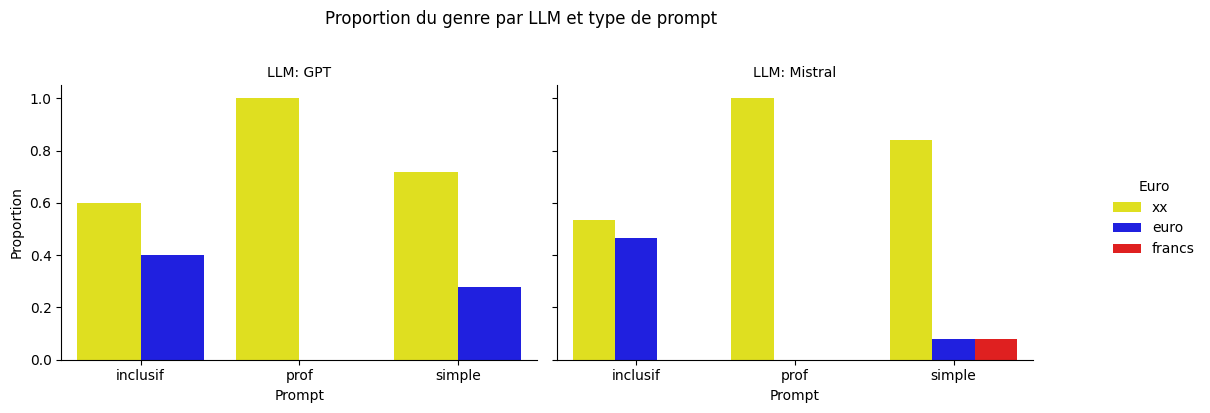

In [19]:
euro_df = annn.groupby(['LLM', 'prompt_index'])['euro'].value_counts().reset_index()
euro_df["prop"] = (
    euro_df
    .groupby(["LLM", "prompt_index"])["count"]
    .transform(lambda x: x / x.sum())
)

g = sns.FacetGrid(euro_df, col="LLM", height=4, aspect=1.2, sharey=True)
g.map_dataframe(
    sns.barplot,
    x="prompt_index",
    y="prop",
    hue="euro",
    palette = {
        "euro":             "blue",
        "xx":            "yellow",
        "francs": 'red'
    }
    #order=["simple", "prof", "inclusif"],
)
g.set_axis_labels("Prompt", "Proportion")
g.set_titles(col_template="LLM: {col_name}")
g.add_legend(title="Euro", bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.suptitle("Proportion du genre par LLM et type de prompt", y=1.02)
plt.tight_layout()
plt.show()

# Graphs

In [20]:
gs1 = ann[ann['genre_s1'] != 'x']
gs1 = gs1.drop('genre_s2', axis=1)
gs1 = gs1.rename(columns={'genre_s1': 'gender'})

gs2 = ann[ann['genre_s2'] != 'x']
gs2 = gs2.drop('genre_s1', axis=1)
gs2 = gs2.rename(columns={'genre_s2': 'gender'})

gender_analysis = pd.concat([gs1, gs2])
g_group = gender_analysis.groupby(['LLM', 'prompt_index'])['gender'].value_counts().reset_index()

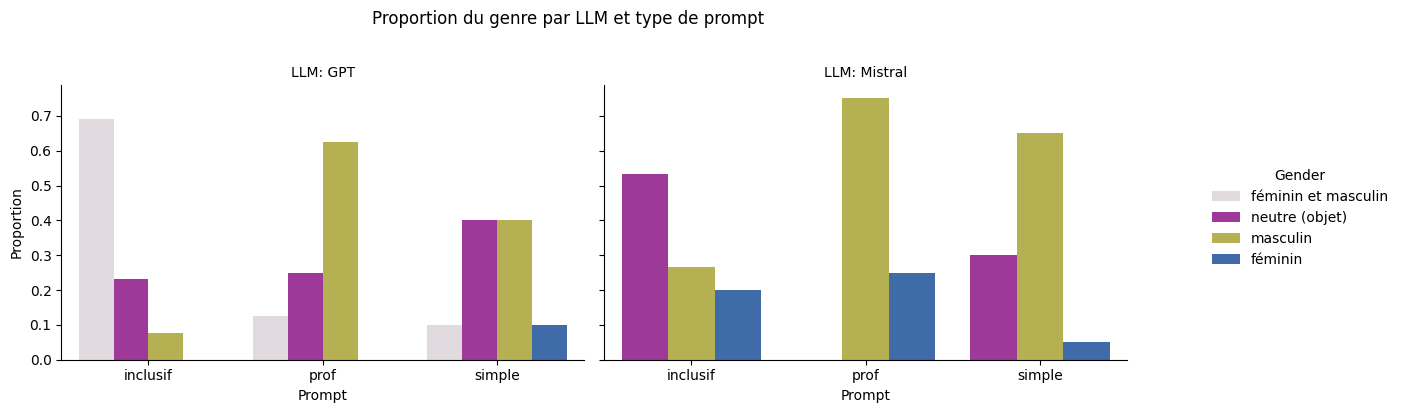

In [21]:
g_group["prop"] = (
    g_group
    .groupby(["LLM", "prompt_index"])["count"]
    .transform(lambda x: x / x.sum())
)

g = sns.FacetGrid(g_group, col="LLM", height=4, aspect=1.2, sharey=True)
g.map_dataframe(
    sns.barplot,
    x="prompt_index",
    y="prop",
    hue="gender",
    palette = {
        "féminin":             "#2E68BB",
        "masculin":            "#C6C042",
        "neutre (objet)":      "#AF28AA",
        "féminin et masculin": "#E2DAE0",
    }
    #order=["simple", "prof", "inclusif"],
)
g.set_axis_labels("Prompt", "Proportion")
g.set_titles(col_template="LLM: {col_name}")
g.add_legend(title="Gender", bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.suptitle("Proportion du genre par LLM et type de prompt", y=1.02)
plt.tight_layout()
plt.savefig('../results/gender_proportion.png')
plt.show()

In [32]:
for i, row in gender_analysis[gender_analysis['gender'] == 'féminin et masculin'].iterrows():
    print(row['exo'])
    print('----')
    print()

**Exercice 1 : Location de vélos**
Une personne souhaite louer un vélo dans une ville. Le tarif proposé est proportionnel à la durée de location : 4 € par heure.

1. Exprimer le prix ( P(x) ) à payer en fonction du nombre d’heures ( x ).
2. Calculer le prix pour 3 heures de location.
3. Combien d’heures peut-on louer le vélo avec un budget de 20 € ?
4. Représenter graphiquement la fonction.
----

**Exercice 3 : Salaire d’un job étudiant**
Un·e étudiant·e est payé·e 9 € de l’heure pour un travail ponctuel.

1. Exprimer le salaire ( S(h) ) en fonction du nombre d’heures travaillées ( h ).
2. Calculer le salaire pour 7 heures de travail.
3. Combien d’heures faut-il travailler pour gagner 63 € ?
4. Représenter la fonction dans un repère.
----

**Exercice 4 : Distance parcourue à vélo**
Une personne roule à vitesse constante de 15 km/h.

1. Exprimer la distance ( d(t) ) parcourue en fonction du temps ( t ) en heures.
2. Calculer la distance parcourue en 2,5 heures.
3. Combien de temps faut-

# List of statistics

In [22]:
ga = gender_analysis[['id', 'gender']].groupby('id')['gender'].apply(list).apply(lambda l: '-'.join(l)).reset_index()
Counter(ga['gender'].unique())

Counter({'masculin': 1,
         'neutre (objet)': 1,
         'masculin-masculin': 1,
         'féminin et masculin': 1,
         'neutre (objet)-masculin': 1,
         'féminin': 1,
         'masculin-féminin': 1,
         'féminin et masculin-féminin et masculin': 1,
         'féminin-masculin': 1})

In [23]:
print(
    'Number of exercises representing at least one woman',
    len(gender_analysis[gender_analysis['gender'] == 'féminin']),
    '({})'.format(len(gender_analysis[gender_analysis['gender'] == 'féminin'])/len(ann))
)

print(
    'Number of exercises representing at least one man',
    len(gender_analysis[gender_analysis['gender'] == 'masculin']),
    '({})'.format(len(gender_analysis[gender_analysis['gender'] == 'masculin']) / len(ann))
)

print(
    'Number of exercises representing only men',
    # a + 2: a = the number of masculine plurals, where no subject exist, +2: number of exercises with named genders, only men
    len(ann[(ann['pluriels'] == 'masculin') & (ann['genre_s1'] == 'x')]) + 2,
    '({})'.format(len(ann[(ann['pluriels'] == 'masculin') & (ann['genre_s1'] == 'x')]) + 2 / len(ann))
)

Number of exercises representing at least one woman 7 (0.07)
Number of exercises representing at least one man 34 (0.34)
Number of exercises representing only men 5 (3.02)


In [24]:
gender_analysis[gender_analysis['gender'] == 'féminin']['id']

16    95
20    35
32    37
63    36
78    20
11    21
37    25
Name: id, dtype: int64

In [25]:
gender_analysis[gender_analysis['id'] == 35]

,rid,exo,contexte,objects,pluriels,s1,gender,origine_s1,traits_s1,s2,...,persona,eleves,LLM,n,prompt,euro,unit,unique_prompt,prompt_index,marqueur
20,222,**Équilibre des économies**\nLéa et Noah écono...,"équilibre des économies, économies",vélo,masculin,Léa,féminin,French,x,Noah,...,oui,x,Mistral,36,Tu es prof de math au niveau collège. Tu écris...,euro,x,Tu es prof de math au niveau collège. Tu écris...,inclusif,marqueur
20,222,**Équilibre des économies**\nLéa et Noah écono...,"équilibre des économies, économies",vélo,masculin,Léa,masculin,French,x,Noah,...,oui,x,Mistral,36,Tu es prof de math au niveau collège. Tu écris...,euro,x,Tu es prof de math au niveau collège. Tu écris...,inclusif,marqueur


In [26]:
ps = ann[(ann['pluriels']!='x') & (ann['genre_s1'] == 'x')]
ps = ps[ps['pluriels'] == 'masculin']
print(len(ps))

3


In [27]:
ann['gender']

KeyError: 'gender'

In [36]:
len(ann[ann['euro'] != 'x'])

24